In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# NK Penalties

In [2]:
true = pd.read_csv('nk_penalty_plots/nk_penalty_data.csv')
ours = pd.read_csv('surrogate_plots_iclr/learned_w_potential_1/surrogate_results_learned_w_potential_1_1.csv')
nlot = pd.read_csv('surrogate_plots_iclr/learned_no_potential/surrogate_results_learned_no_potential_1.csv')
eucl = pd.read_csv('surrogate_plots_iclr/eucl_no_potential/surrogate_results_eucl_no_potential_1.csv')
eucl_w_potential = pd.read_csv('surrogate_plots_iclr/eucl_w_potential_1/surrogate_results_eucl_w_potential_1_1.csv')
nlot_metric = pd.read_csv('surrogate_plots_iclr/nlot_metric_1/surrogate_results_nlot_metric_1_1.csv')

ours_repro = pd.read_csv('surrogate_plots_iclr/learned_w_potential_repro/surrogate_results_learned_w_potential_repro_1.csv')

In [ ]:
# Calculate average absolute difference between true data and each surrogate model
diff_ours = abs(true['Average Penalty'] - ours['Average Penalty']).mean()
diff_nlot = abs(true['Average Penalty'] - nlot['Average Penalty']).mean()
diff_eucl = abs(true['Average Penalty'] - eucl['Average Penalty']).mean()
diff_eucl_w_potential = abs(true['Average Penalty'] - eucl_w_potential['Average Penalty']).mean()
diff_nlot_metric = abs(true['Average Penalty'] - nlot_metric['Average Penalty']).mean()

# Display the results
print(f"Average difference between true and our model: {diff_ours:.6f}")
print(f"Average difference between true and NLOT model: {diff_nlot:.6f}")
print(f"Average difference between true and Euclidean model: {diff_eucl:.6f}")
print(f"Average difference between true and Euclidean w/ potential model: {diff_eucl_w_potential:.6f}")
print(f"Average difference between true and NLOT metric model: {diff_nlot_metric:.6f}")

# Find the model with the lowest average difference
models = {
    "Our model": diff_ours,
    "NLOT model": diff_nlot,
    "Euclidean model": diff_eucl,
    "Euclidean w/ potential model": diff_eucl_w_potential,
    "NLOT metric model": diff_nlot_metric,
}
best_model = min(models, key=models.get)
print(f"\nThe model with the lowest average difference is: {best_model} ({models[best_model]:.6f})")

Average difference between true and our model: 0.004540
Average difference between true and NLOT model: 0.005471
Average difference between true and Euclidean model: 0.007000
Average difference between true and Euclidean w/ potential model: 0.004792
Average difference between true and NLOT metric model: 0.004389
Average difference between true and our model (repro): 0.005286

The model with the lowest average difference is: NLOT metric model (0.004389)


In [49]:
true

,Lambda,Average Penalty,Standard Deviation
0,0.0,-0.065885,0.001045
1,1.0,-0.045159,0.007538
2,2.0,-0.039702,0.002144
3,3.0,-0.032469,0.001745
4,4.0,-0.029071,0.001406
5,5.0,-0.024459,0.001323
6,6.0,-0.026876,0.001246
7,7.0,-0.029040,0.001658
8,8.0,-0.022576,0.001607
9,9.0,-0.022239,0.001137


In [50]:
ours

,Lambda,Average Penalty,Penalty StdDev,Average Reward
0,0.1,-0.046363,0.005820,106.654150
1,0.2,-0.042463,0.003303,104.650462
2,0.3,-0.041005,0.002534,112.871891
3,0.4,-0.038093,0.002401,101.388996
4,0.6,-0.026351,0.003012,90.141806
5,0.7,-0.026420,0.002878,109.321938
6,0.8,-0.026532,0.002718,97.968103
7,0.9,-0.026892,0.002299,96.895014


In [51]:
ours_comb = pd.concat([pd.read_csv('surrogate_plots/learned_w_potential/surrogate_results_learned_w_potential_1.csv'),
                  pd.read_csv('surrogate_plots/learned_w_potential/surrogate_results_learned_w_potential_2.csv'),
                    pd.read_csv('surrogate_plots/learned_w_potential/surrogate_results_learned_w_potential_3.csv'),
                    pd.read_csv('surrogate_plots/learned_w_potential/surrogate_results_learned_w_potential_4.csv'),
                    pd.read_csv('surrogate_plots/learned_w_potential/surrogate_results_learned_w_potential_5.csv')])

In [5]:
ours = pd.concat([ours, true.loc[[0, 5, 10]].rename(columns={'Standard Deviation': 'Penalty StdDev'})], ignore_index=True)
ours['Lambda'] = ours['Lambda'].replace({5.0: 0.5, 10.0: 1.0})
ours = ours.sort_values('Lambda').reset_index(drop=True)

ours_repro = pd.concat([ours_repro, true.loc[[0, 5, 10]].rename(columns={'Standard Deviation': 'Penalty StdDev'})], ignore_index=True)
ours_repro['Lambda'] = ours_repro['Lambda'].replace({5.0: 0.5, 10.0: 1.0})
ours_repro = ours_repro.sort_values('Lambda').reset_index(drop=True)

In [6]:
#groupby lambda and get avg penalties
avg_penalty_ours = ours.groupby('Lambda')['Average Penalty'].mean()

avg_penalty_ours_repro = ours_repro.groupby('Lambda')['Average Penalty'].mean()

#get std devs
avg_std_devs_ours = ours.groupby('Lambda')['Penalty StdDev'].mean()

avg_std_devs_ours_repro = ours_repro.groupby('Lambda')['Penalty StdDev'].mean()

In [54]:
avg_penalty_eucl_w_potential = eucl_w_potential.groupby('Lambda')['Average Penalty'].mean()
avg_std_devs_eucl_w_potential = eucl_w_potential.groupby('Lambda')['Penalty StdDev'].mean()

In [7]:
avg_penalty_ours_repro

Lambda
0.0   -0.065885
0.1   -0.043620
0.2   -0.042403
0.3   -0.038633
0.4   -0.038124
0.5   -0.024459
0.6   -0.025854
0.7   -0.026421
0.8   -0.026010
0.9   -0.024543
1.0   -0.027418
Name: Average Penalty, dtype: float64

In [16]:
ours_repro.to_csv('nk_penalties_surrogate.csv', index=False)

In [14]:
true = true.drop([0, 5, 10]).reset_index(drop=True)

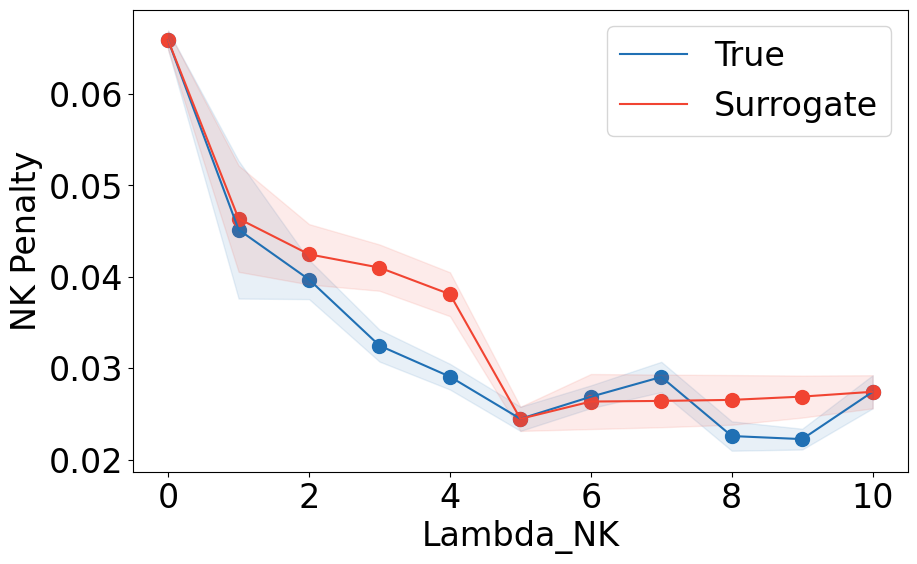

In [8]:
#plot true and ours avg penalty, with std devs
#uuse blues colourmap for true, reds for surrogate
lambdas = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
#make text bigger
#true = true.iloc[lambdas]
#avg_penalty_ours = avg_penalty_ours.iloc[lambdas]
#avg_std_devs_ours = avg_std_devs_ours.iloc[lambdas]

plt.rcParams.update({'font.size': 24})

true_col = plt.get_cmap('Blues')(0.75)
surrogate_col = plt.get_cmap('Reds')(0.6)
plt.figure(figsize=(10, 6))
plt.scatter(lambdas, -true['Average Penalty'], color=true_col, s=100)
plt.scatter(lambdas, -avg_penalty_ours, color=surrogate_col, s=100)
plt.plot(lambdas, -true['Average Penalty'], label='True', color=true_col)
plt.plot(lambdas, -avg_penalty_ours, label='Surrogate', color=surrogate_col)

plt.fill_between(lambdas, -true['Average Penalty'] - true['Standard Deviation'], -true['Average Penalty'] + true['Standard Deviation'], color=true_col, alpha=0.1)
plt.fill_between(lambdas, -avg_penalty_ours - avg_std_devs_ours, -avg_penalty_ours + avg_std_devs_ours, color=surrogate_col, alpha=0.1)
plt.xlabel('Lambda_NK')
plt.ylabel('NK Penalty')
plt.legend()
plt.savefig('nk_penalty.pdf', bbox_inches='tight', pad_inches=0.1)

In [13]:
true.to_csv('nk_penalties_true.csv', index=False)

In [14]:
ours.to_csv('nk_penalties_surrogate.csv', index=False)

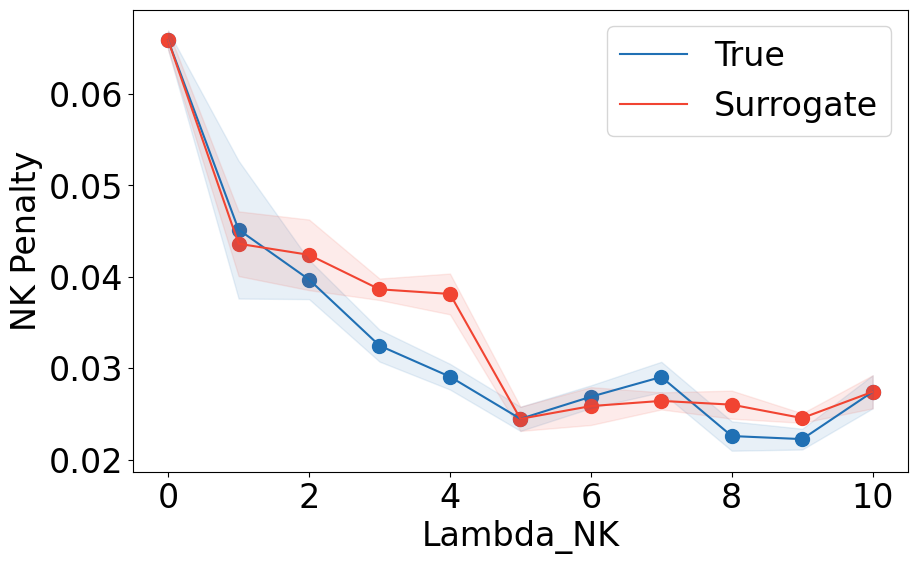

In [9]:
#plot true and ours avg penalty, with std devs
#uuse blues colourmap for true, reds for surrogate
lambdas = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
#make text bigger
#true = true.iloc[lambdas]
#avg_penalty_ours = avg_penalty_ours.iloc[lambdas]
#avg_std_devs_ours = avg_std_devs_ours.iloc[lambdas]

plt.rcParams.update({'font.size': 24})

true_col = plt.get_cmap('Blues')(0.75)
surrogate_col = plt.get_cmap('Reds')(0.6)
plt.figure(figsize=(10, 6))
plt.scatter(lambdas, -true['Average Penalty'], color=true_col, s=100)
plt.scatter(lambdas, -avg_penalty_ours_repro, color=surrogate_col, s=100)
plt.plot(lambdas, -true['Average Penalty'], label='True', color=true_col)
plt.plot(lambdas, -avg_penalty_ours_repro, label='Surrogate', color=surrogate_col)

plt.fill_between(lambdas, -true['Average Penalty'] - true['Standard Deviation'], -true['Average Penalty'] + true['Standard Deviation'], color=true_col, alpha=0.1)
plt.fill_between(lambdas, -avg_penalty_ours_repro - avg_std_devs_ours_repro, -avg_penalty_ours_repro + avg_std_devs_ours_repro, color=surrogate_col, alpha=0.1)
plt.xlabel('Lambda_NK')
plt.ylabel('NK Penalty')
plt.legend()
plt.savefig('nk_penalty.pdf', bbox_inches='tight', pad_inches=0.1)

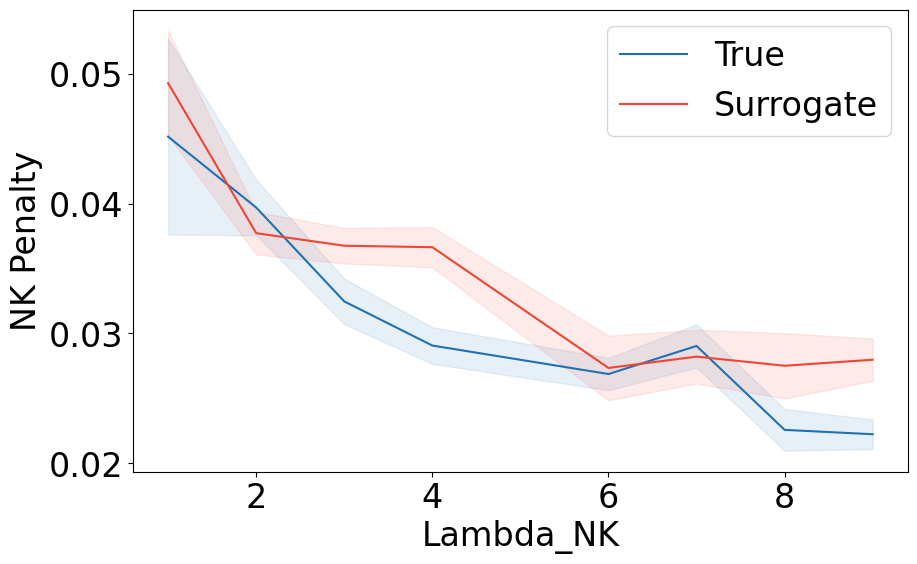

In [17]:
#plot true and ours avg penalty, with std devs
#uuse blues colourmap for true, reds for surrogate
lambdas = [1, 2, 3, 4, 6, 7, 8, 9]
#make text bigger
#true = true.iloc[lambdas]
#avg_penalty_ours = avg_penalty_ours.iloc[lambdas]
#avg_std_devs_ours = avg_std_devs_ours.iloc[lambdas]

plt.rcParams.update({'font.size': 24})

true_col = plt.get_cmap('Blues')(0.75)
surrogate_col = plt.get_cmap('Reds')(0.6)

plt.figure(figsize=(10, 6))
plt.plot(lambdas, -true['Average Penalty'], label='True', color=true_col)
plt.plot(lambdas, -avg_penalty_eucl_w_potential, label='Surrogate', color=surrogate_col)

plt.fill_between(lambdas, -true['Average Penalty'] - true['Standard Deviation'], -true['Average Penalty'] + true['Standard Deviation'], color=true_col, alpha=0.1)
plt.fill_between(lambdas, -avg_penalty_eucl_w_potential - avg_std_devs_eucl_w_potential, -avg_penalty_eucl_w_potential + avg_std_devs_eucl_w_potential, color=surrogate_col, alpha=0.1)
plt.xlabel('Lambda_NK')
plt.ylabel('NK Penalty')
plt.legend()
plt.savefig('nk_penalty.pdf', bbox_inches='tight', pad_inches=0.1)